In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
df = pd.read_csv('Agri_Data_Cleaned.csv')
target = "NDVI"
df.head()

,AP_Ratio,District,Season,Avg_Humidity,Crop_Name,Transplant,Growth,NDVI,EVI,LAI,FPAR,Soil_Moisture_mm,Avg_Salinity_Index,pH,Organic_Carbon,Nitrogen,Clay,Silt,CN_Ratio,Dominant_Soil_Texture,Rainfall,Temp_Mean,Temp_Max,Temp_Min,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,LST_C
0,2.9175,Gazipur,Kharif 1,65.0000,Taramind,February,March To April,0.3007,0.5490,1.0555,0.0185,25.8147,788.0503,5.7400,16.6800,1.3600,33.7900,33.0400,12.2700,Loamy,"1,035.8500",25.7449,37.6800,16.4100,46,2.4247,6.3000,40.2300,24.5695
1,0.9561,Munshiganj,Kharif 1,72.5000,Aus,March,April To July,0.3475,0.6378,1.0719,0.0319,28.6055,897.4539,5.3200,19.2800,1.7700,34.8100,36.8700,10.8800,Loamy,899.6400,29.7438,37.7300,15.4800,51,2.9399,6.0800,30.2500,27.5377
2,2.5255,Brahmanbaria,Kharif 2,67.5000,Tobacco,October,Nov To Feb,0.3110,0.5702,0.9584,0.0243,24.6311,757.6894,5.4900,25.6900,2.8300,33.8100,38.5500,9.0700,Loamy,"1,124.1600",27.6812,33.8700,18.7200,0,1.6234,5.6600,40.6100,27.9589
3,0.9546,Khagrachari,Kharif 1,72.5000,Aus,March,April To July,0.3981,0.6884,1.3651,0.0280,28.1302,618.0393,5.6800,16.7400,1.5400,30.2800,37.4200,10.8800,Loamy,"1,103.4000",26.3564,38.7000,12.5300,25,0.2013,0.9500,41.8600,25.3887
4,3.4513,Sirajganj,Rabi,60.0000,Maize 2,December,Jan To March,0.4008,0.6831,1.5209,0.0332,7.7033,939.4532,6.1700,22.3800,1.3300,41.3400,37.2800,16.8100,Clayey,85.7200,19.2166,30.4000,8.2300,0,1.3789,4.3700,4.4600,23.3376


# Data Visualization


## 1. Phân phối biến mục tiêu NDVI


count   9,998.0000
mean        0.3876
std         0.1039
min         0.0000
25%         0.3278
50%         0.3931
75%         0.4517
max         0.7796
Name: NDVI, dtype: float64


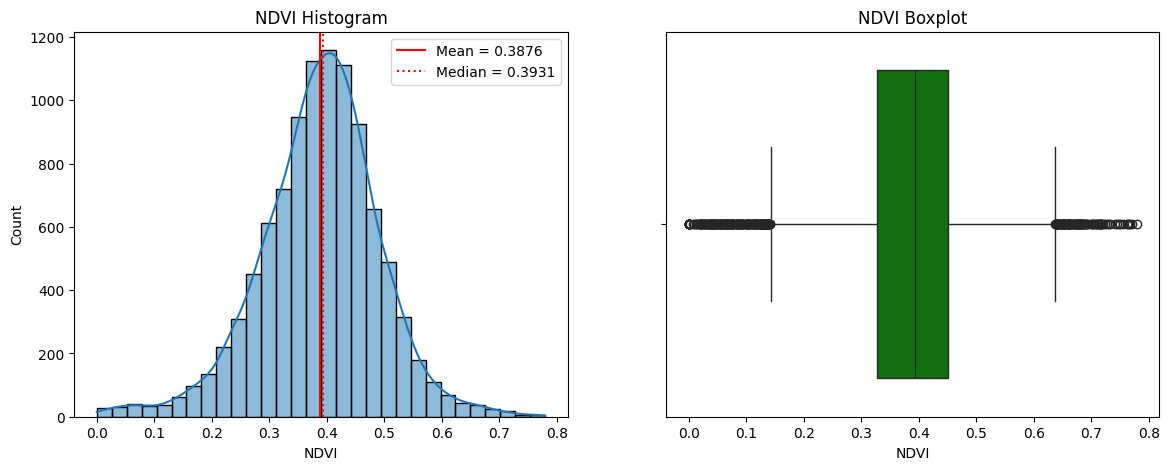

In [13]:
print(df[target].describe())

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.histplot(df[target], bins = 30, kde = True, ax = axes[0])
axes[0].axvline(df[target].mean(), linestyle = '-', color = 'red', label = f'Mean = {df[target].mean():.4f}')
axes[0].axvline(df[target].median(), linestyle = ':', color = 'red', label = f'Median = {df[target].median():.4f}')

axes[0].set_title('NDVI Histogram')
axes[0].legend()

sns.boxplot(x = df[target], color = 'green', ax = axes[1])
axes[1].set_title('NDVI Boxplot')
plt.show()

## 2. NDVI theo mùa vụ


,count,mean,median,std,min,max
Season,,,,,,
Kharif 1,3326,0.3121,0.3159,0.0875,0.0000,0.5273
Kharif 2,3892,0.4176,0.4200,0.0940,0.0071,0.7020
Rabi,2780,0.4362,0.4286,0.0826,0.1862,0.7796


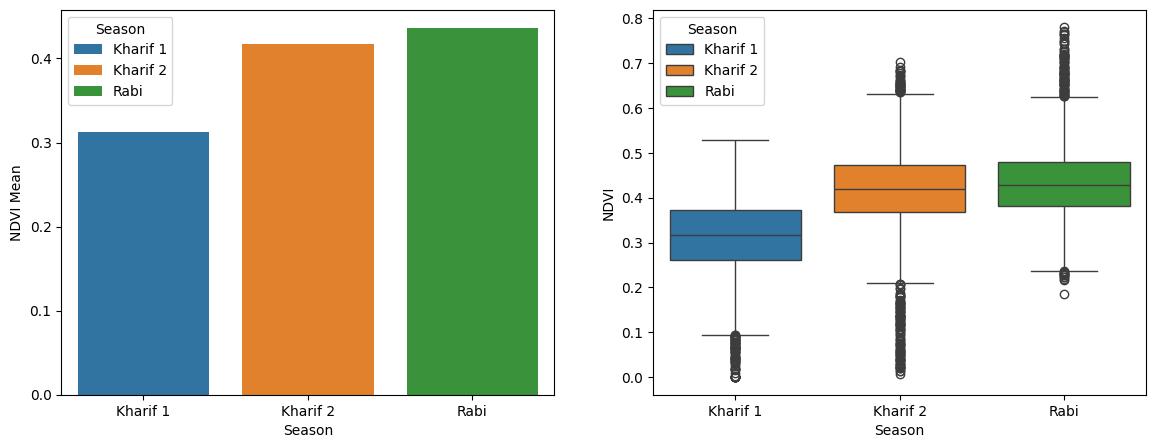

In [16]:
season_summary = (df.groupby('Season')[target]
                  .agg(count = 'count', mean = 'mean', median = 'median', std = 'std', min = 'min', max = 'max')
                  .sort_values('mean', ascending = True))
display(season_summary)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.barplot(data = season_summary,
            x = 'Season',
            y = 'mean',
            hue = 'Season',
            ax = axes[0],
           legend = True)

axes[0].set_ylabel('NDVI Mean')

sns.boxplot(data = df,
            x = 'Season',
            y = target,
            hue = 'Season',
            ax = axes[1],
           legend = True)


plt.show()

## 3. NDVI theo cây trồng và sự phụ thuộc Crop–Season


,count,mean,median,std
Crop_Name,,,,
Banana,139,0.5112,0.5060,0.0717
Boro,139,0.4928,0.4829,0.0747
Palmyra Palm,139,0.4922,0.4829,0.0707
Lemon,139,0.4899,0.4747,0.0820
Betelnut,139,0.4884,0.4891,0.0792


,count,mean,median,std
Crop_Name,,,,
Beans,138,0.2591,0.2597,0.0853
Jhinga,139,0.2585,0.2633,0.0854
Kakrol,139,0.2582,0.2612,0.0752
Mukhi Kachu,139,0.2507,0.2498,0.0860
Kolmi Shak,139,0.2436,0.2549,0.0762


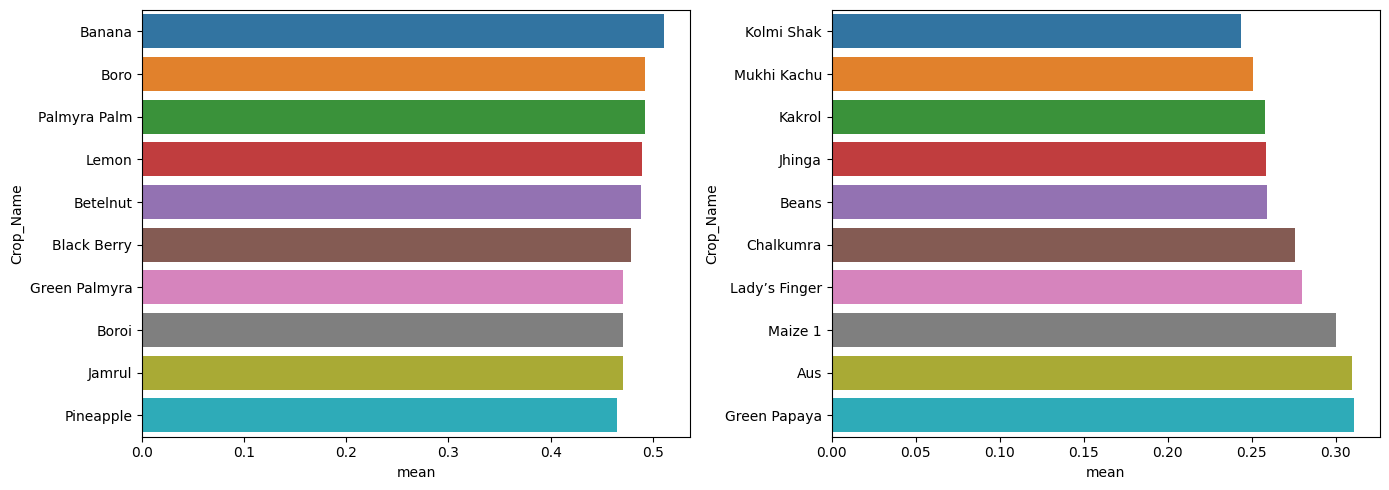

In [18]:
summary_crop = (df.groupby('Crop_Name')[target]
                .agg(count = 'count', mean = 'mean', median = 'median', std = 'std')
                .sort_values(by = 'mean', ascending = False))
display(summary_crop.head())
print()
display(summary_crop.tail())

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.barplot(data = summary_crop.head(10),
            x = 'mean',
            y = 'Crop_Name',
            hue = 'Crop_Name',
            ax = axes[0])

sns.barplot(data = summary_crop.tail(10).sort_values(by = 'mean', ascending = True),
            x = 'mean',
            y = 'Crop_Name',
            hue = 'Crop_Name',
            ax = axes[1])

plt.tight_layout()
plt.show()

## 4. NDVI theo khu vực


,count,mean,median,std
District,,,,
Sunamganj,160,0.1728,0.0713,0.1803
Kishoreganj,147,0.2309,0.1804,0.1203
Bhola,147,0.2560,0.2527,0.0445
Netrokona,173,0.2730,0.2995,0.1120
Sirajganj,162,0.2854,0.2726,0.0727
Kurigram,157,0.3063,0.3167,0.0788
Dhaka,150,0.3218,0.3194,0.0641
Gaibandha,149,0.3235,0.3337,0.0633
Sylhet,149,0.3280,0.3731,0.1340


,count,mean,median,std
District,,,,
Chuadanga,151,0.4519,0.4375,0.0692
Pirojpur,135,0.4577,0.4665,0.0704
Jhenaidah,150,0.4582,0.4576,0.0614
Chattogram,154,0.4699,0.4770,0.0689
Meherpur,169,0.4708,0.4646,0.0663
Gopalganj,165,0.4770,0.4790,0.0642
Jhallokati,154,0.4862,0.4983,0.0668
Rangamati,179,0.5264,0.5543,0.1027
Khagrachari,152,0.5528,0.5835,0.1130


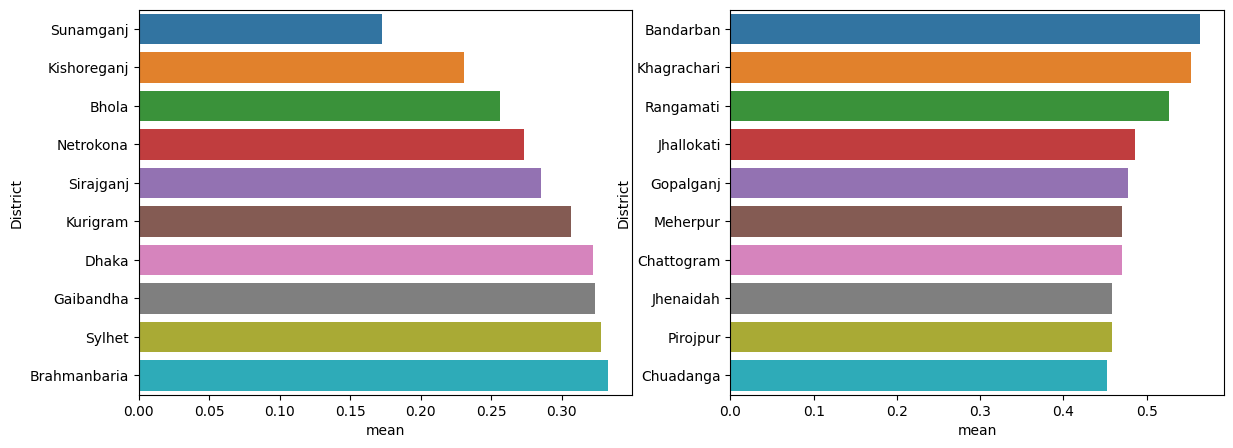

In [19]:
district_summary = (df.groupby('District')[target]
                    .agg(count = 'count', mean = 'mean', median = 'median', std = 'std')
                    .sort_values(by = 'mean', ascending = True))
display(district_summary.head(10))
print()
display(district_summary.tail(10))

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.barplot(data = district_summary.head(10),
            x = 'mean',
            y = 'District',
            hue = 'District',
            ax = axes[0])

sns.barplot(data = district_summary.tail(10).sort_values(by = 'mean', ascending = False),
            x = 'mean',
            y = 'District',
            hue = 'District',
            ax = axes[1])
plt.show()

## 5. Tương quan giữa các biến số


,Correlation
Avg_Salinity_Index,-0.5764
LST_C,-0.3570
Wind_Mean,-0.3359
Temp_Max,-0.3359
Rainfall,-0.3326
Rain_Temp_Ratio,-0.3270
Heat_Stress_Days,-0.3255
Temp_Mean,-0.2960
Soil_Moisture_mm,-0.2903
Wind_Max,-0.1538


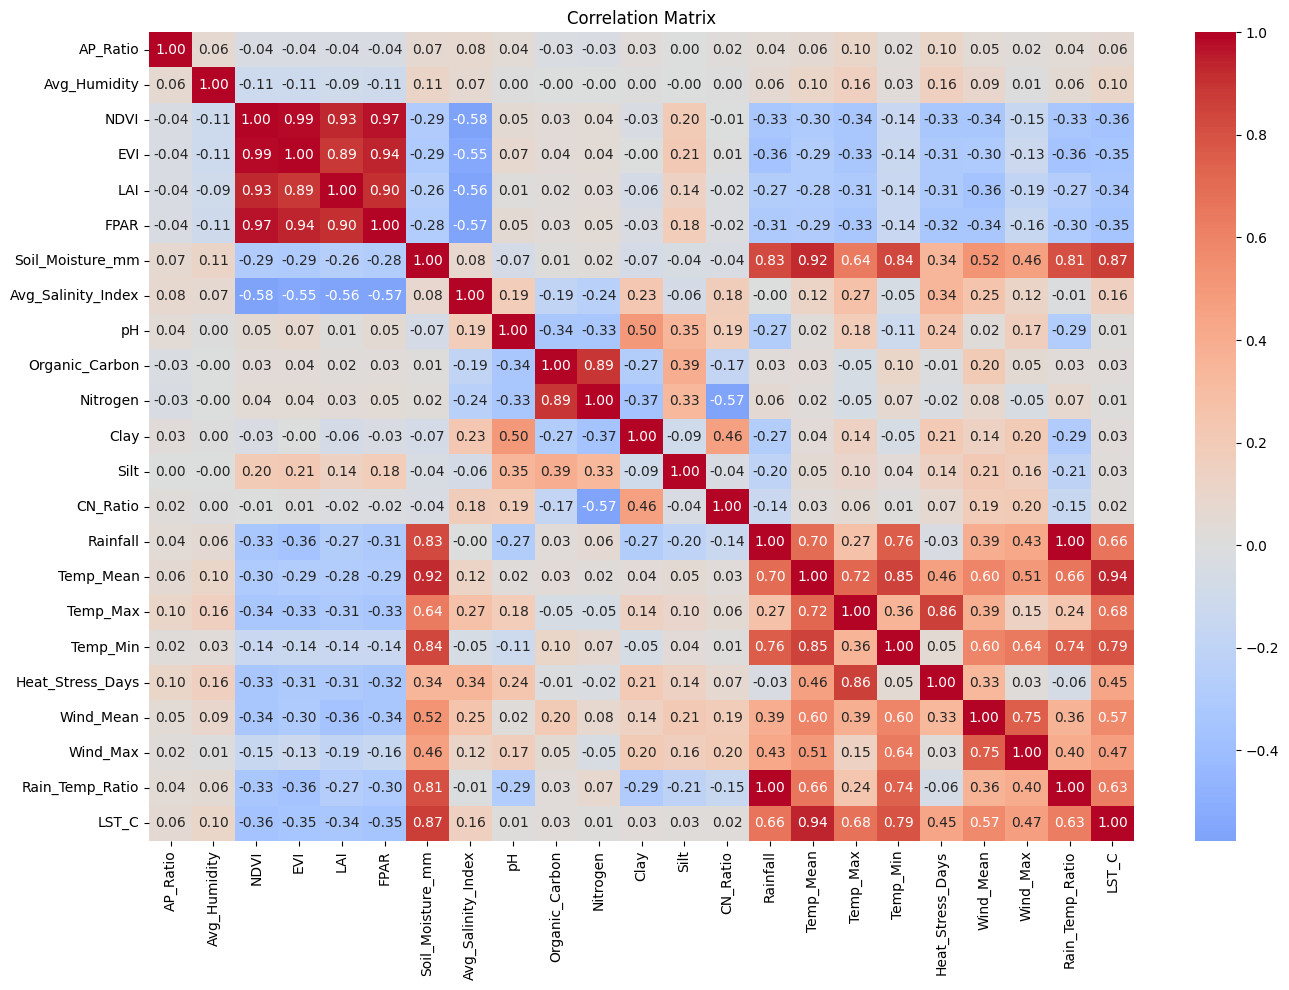

In [ ]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

target_corr = corr_matrix[target].sort_values()
display(target_corr.to_frame('Correlation'))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap ="coolwarm",
    center = 0,
    annot = True,
    fmt = ".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Độ mặn và NDVI


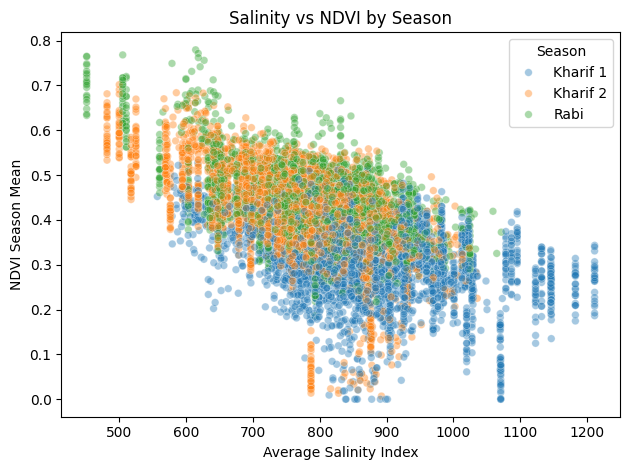

In [ ]:
sns.scatterplot(
    data = df,
    x = "Avg_Salinity_Index",
    y = target,
    hue = "Season",
    alpha = 0.4,
    s = 30
)

plt.title("Salinity vs NDVI by Season")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

## 7. Nhiệt độ, stress nhiệt và NDVI — kiểm tra confounding theo Season

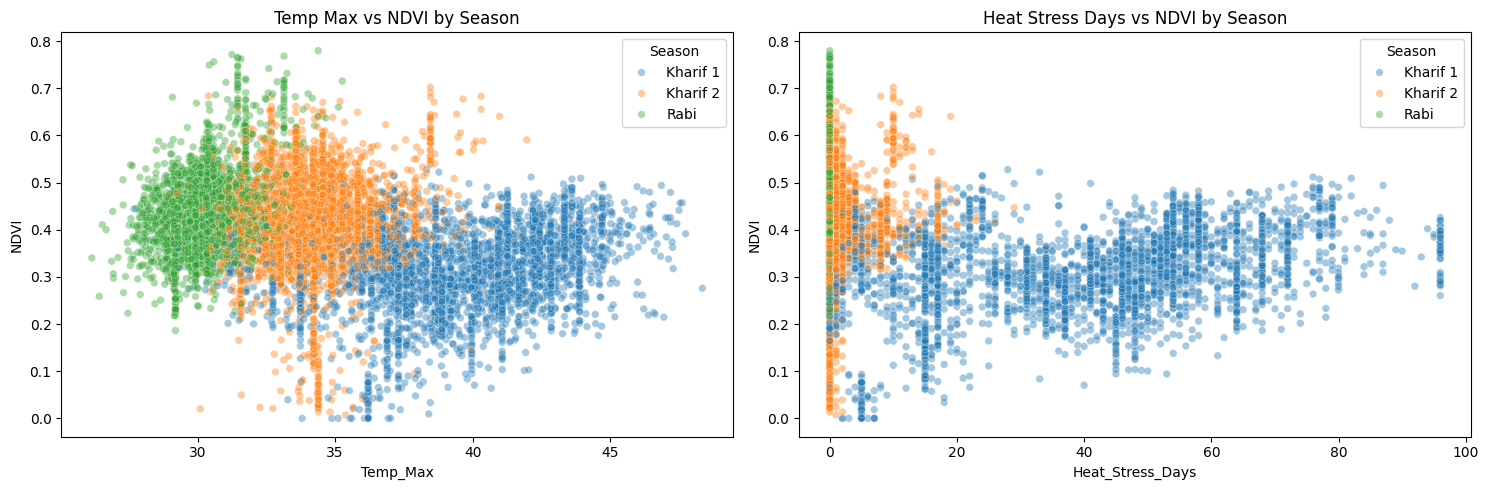

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data = df,
    x = "Temp_Max",
    y = target,
    hue = "Season",
    alpha = 0.4,
    s = 30,
    ax = axes[0]
)

sns.scatterplot(
    data = df,
    x = "Heat_Stress_Days",
    y = target,
    hue = "Season",
    alpha = 0.4,
    s = 30,
    ax = axes[1]
)

axes[0].set_title("Temp Max vs NDVI by Season")
axes[1].set_title("Heat Stress Days vs NDVI by Season")

plt.tight_layout()
plt.show()

## 8. Độ ẩm đất, lượng mưa và NDVI


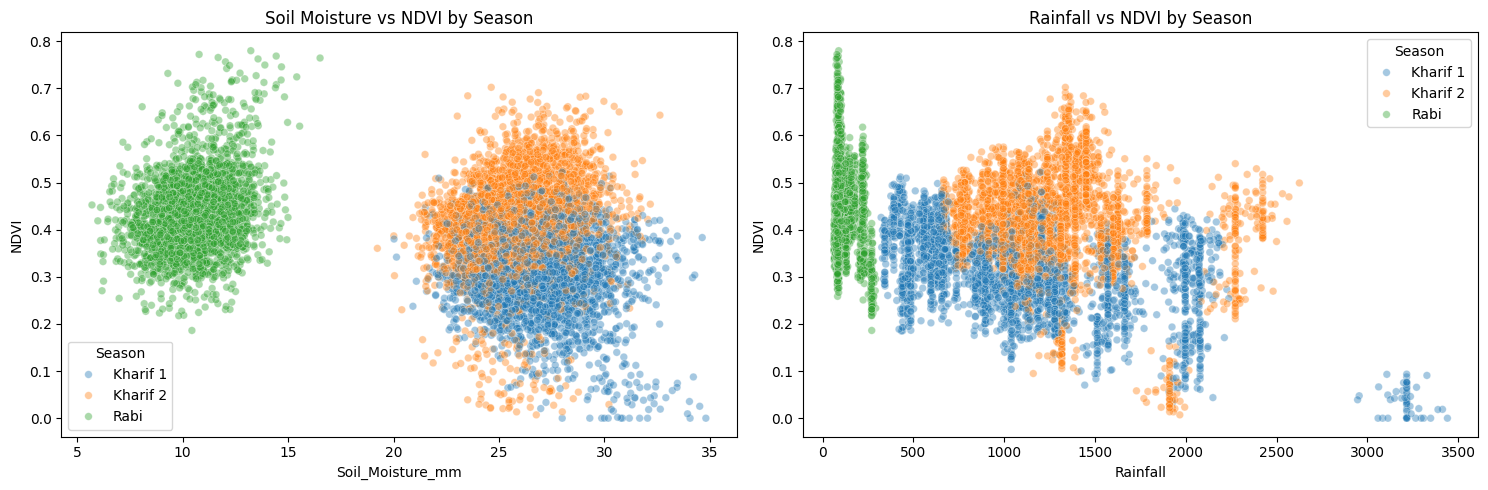

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data = df,
    x = "Soil_Moisture_mm",
    y = target,
    hue = "Season",
    alpha = 0.4,
    s = 30,
    ax = axes[0]
)

sns.scatterplot(
    data = df,
    x = "Rainfall",
    y = target,
    hue = "Season",
    alpha = 0.4,
    s = 30,
    ax = axes[1]
)

axes[0].set_title("Soil Moisture vs NDVI by Season")
axes[1].set_title("Rainfall vs NDVI by Season")

plt.tight_layout()
plt.show()

In [ ]:
fig = px.scatter(
    df,
    x = "Soil_Moisture_mm",
    y = target,
    color = "Season",
    hover_data = ["Crop_Name", "District", "Rainfall", "Heat_Stress_Days", "Avg_Salinity_Index"],
    title = "Interactive Scatter Plot: Soil Moisture vs NDVI"
)
fig.update_layout(
    xaxis_title = "Soil Moisture (mm)",
    yaxis_title = "NDVI",
    legend_title = "Season"
)
fig.show()